In [ ]:
# Cell 1: Configure Logging and Environment
import os
import warnings
import logging
from absl import logging as absl_logging

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['GLOG_minloglevel'] = '3'
os.environ['ABSL_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings("ignore")
logging.getLogger('tensorflow').setLevel(logging.ERROR)
absl_logging.set_verbosity(absl_logging.ERROR)
tf_logger = logging.getLogger('tensorflow')
tf_logger.setLevel(logging.ERROR)

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
print("Cell 1: Logging and warnings configured.")

Cell 1: Logging and warnings configured.


In [ ]:
# Cell 3: Import Main Libraries
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
import json
import sys
import mediapipe as mp
import contextlib
import pickle
from tqdm import tqdm
import time
from IPython.display import clear_output, display
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models, optimizers, losses, metrics, callbacks
from tensorflow.keras.applications import MobileNetV3Small

print("TensorFlow Version:", tf.__version__)
print("NumPy Version:", np.__version__)
print("OpenCV Version:", cv2.__version__)
print("MediaPipe Version:", mp.__version__)
print("Cell 3: Main libraries imported.")

TensorFlow Version: 2.20.0-dev20250413
NumPy Version: 1.26.4
OpenCV Version: 4.11.0
MediaPipe Version: 0.10.21
Cell 3: Main libraries imported.


In [ ]:
# Cell 4: Set Working Directory
tf.config.optimizer.set_jit(False)
print("XLA JIT compilation disabled.")
desired_directory = "/home/cc"
try:
    os.chdir(desired_directory)
    print(f"Working directory set to: {os.getcwd()}")
except FileNotFoundError:
    print(f"Error: Could not change directory to '{desired_directory}'. Please ensure it exists.")
lrw_root_path = os.getcwd() # Define root path after setting directory

XLA JIT compilation disabled.
Working directory set to: /home/cc


In [ ]:
# Cell 5: Configure Mixed Precision and Check GPU

# --- Enable Mixed Precision ---
print("Configuring mixed precision...")
from tensorflow.keras import mixed_precision
policy_name = 'mixed_float16'
try:
    policy = mixed_precision.Policy(policy_name)
    mixed_precision.set_global_policy(policy)
    print(f'Mixed precision policy set to: {policy.name}')
    print('Compute dtype: %s' % policy.compute_dtype)
    print('Variable dtype: %s' % policy.variable_dtype)
except Exception as e:
    print(f"Could not set mixed precision policy '{policy_name}'. Error: {e}")
    print("Proceeding with default float32 policy.")

# --- GPU Check ---
print("\n--- GPU Check ---")
gpus = tf.config.list_physical_devices('GPU')
device = '/CPU:0' # Default to CPU
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.list_logical_devices('GPU')
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
        details = tf.config.experimental.get_device_details(gpus[0])
        print(f"GPU Name: {details.get('device_name', 'N/A')}")
        device = '/GPU:0'
    except RuntimeError as e:
        print(f"Error during GPU setup: {e}")
else:
    print("No GPU detected, using CPU.")

print(f"Using device: {device}")
print("\nCell 5: Mixed Precision and GPU Check Complete.")

Configuring mixed precision...
Mixed precision policy set to: mixed_float16
Compute dtype: float16
Variable dtype: float32

--- GPU Check ---
1 Physical GPUs, 1 Logical GPUs
GPU Name: Quadro RTX 6000
Using device: /GPU:0

Cell 5: Mixed Precision and GPU Check Complete.


In [ ]:
# Cell 6: Define Parameters (64x64 Resolution)
print("\n--- Parameters & Path Verification (64x64 Resolution) ---")

# --- TARGET WORD LIST ---
TARGET_WORDS = [
    "AFTER", "AGAIN", "ALREADY", "ALWAYS", "AMONG", "ACROSS", "PEOPLE", "YEARS",
    "TIMES", "BEING", "BETWEEN", "EVERY", "EVERYONE", "SOMETHING", "SOMEONE",
    "STILL", "WHILE", "WITHIN", "WITHOUT", "TOGETHER", "TOWARDS", "OTHER", "OTHERS",
    "ANOTHER", "ANYTHING", "AROUND", "BECAUSE", "BECOME", "GETTING", "GIVING", "GOING",
    "KNOWN", "LITTLE", "LONGER", "LOOKING", "MAKING", "MAJORITY", "MEANS", "MASSIVE",
    "NEEDS", "PARTY", "PERHAPS", "PLACES", "POINT", "POSSIBLE", "PROBABLY", "QUITE",
    "RATHER", "REALLY", "RIGHT", "SAYING", "SECOND", "SEEMS", "SHOULD", "SIMPLY",
    "SINCE", "SMALL", "STARTED", "STATE", "YESTERDAY"
]
TARGET_WORDS = sorted(list(set(TARGET_WORDS)))
NUM_TARGET_WORDS = len(TARGET_WORDS)
print(f"Number of unique target words: {NUM_TARGET_WORDS}")

# --- Parameters ---
BATCH_SIZE = 32 # Keep or adjust based on memory
IMG_WIDTH = 64
IMG_HEIGHT = 64
NUM_FRAMES = 29
NUM_CLASSES = NUM_TARGET_WORDS
GRAYSCALE = True
FACE_MESH_MARGIN = 0.3

# --- Derived Parameters ---
IMG_SHAPE = (IMG_HEIGHT, IMG_WIDTH, 1 if GRAYSCALE else 3)
INPUT_SHAPE = (NUM_FRAMES, IMG_HEIGHT, IMG_WIDTH, 1 if GRAYSCALE else 3)

print(f"LRW dataset path assumed to be: {lrw_root_path}")
print(f"Target image size: {IMG_WIDTH}x{IMG_HEIGHT}")
print(f"Expected model input shape: {INPUT_SHAPE}")
print(f"Number of classes: {NUM_CLASSES}")

# --- Verify Dataset Structure ) ---
lipread_subdir = os.path.join(lrw_root_path, "lipread_mp4")
if os.path.exists(lipread_subdir) and os.path.isdir(lipread_subdir):
    print(f"Found subdirectory: '{lipread_subdir}'")
    example_target_word_dir = os.path.join(lipread_subdir, TARGET_WORDS[0])
    if os.path.exists(example_target_word_dir) and os.path.isdir(example_target_word_dir):
         print(f"Found example target word directory: '{example_target_word_dir}'")
    else:
         print(f"Warning: Example target word directory ('{TARGET_WORDS[0]}') not found.")
else:
    print(f"ERROR: Subdirectory 'lipread_mp4' NOT found.")

print("\nCell 6: Parameters Updated (64x64).")


--- Parameters & Path Verification (64x64 Resolution) ---
Number of unique target words: 60
LRW dataset path assumed to be: /home/cc
Target image size: 64x64
Expected model input shape: (29, 64, 64, 1)
Number of classes: 60
Found subdirectory: '/home/cc/lipread_mp4'
Found example target word directory: '/home/cc/lipread_mp4/ACROSS'

Cell 6: Parameters Updated (64x64).


In [ ]:
# Cell 7: Define Preprocessing Functions
print("\n--- Preprocessing Function Definitions ---")

# Define mouth landmarks indices
MOUTH_LANDMARKS_OUTER = [61, 146, 91, 181, 84, 17, 314, 405, 321, 375, 291]
MOUTH_LANDMARKS_TO_USE = MOUTH_LANDMARKS_OUTER

# Define process_frame function
def process_frame(frame, face_mesh, margin=FACE_MESH_MARGIN, target_size=(IMG_WIDTH, IMG_HEIGHT)):
    h, w, _ = frame.shape
    img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    img_rgb.flags.writeable = False
    results = face_mesh.process(img_rgb)
    img_rgb.flags.writeable = True
    processed_frame = None
    if results.multi_face_landmarks:
        face_landmarks = results.multi_face_landmarks[0]
        pts = []
        for idx in MOUTH_LANDMARKS_TO_USE:
            if idx < len(face_landmarks.landmark):
                 lm = face_landmarks.landmark[idx]
                 if 0 <= lm.x <= 1 and 0 <= lm.y <= 1:
                      pts.append((int(lm.x * w), int(lm.y * h)))
        if len(pts) > 3:
            pts = np.array(pts)
            x_min, y_min = np.min(pts, axis=0)
            x_max, y_max = np.max(pts, axis=0)
            center_x = (x_min + x_max) / 2
            center_y = (y_min + y_max) / 2
            crop_size = max(x_max - x_min, y_max - y_min)
            crop_size_margin = int(crop_size * (1 + 2 * margin))
            x_min_sq = int(center_x - crop_size_margin / 2)
            x_max_sq = int(center_x + crop_size_margin / 2)
            y_min_sq = int(center_y - crop_size_margin / 2)
            y_max_sq = int(center_y + crop_size_margin / 2)
            x_min_sq_clipped = max(0, x_min_sq)
            y_min_sq_clipped = max(0, y_min_sq)
            x_max_sq_clipped = min(w, x_max_sq)
            y_max_sq_clipped = min(h, y_max_sq)
            if y_min_sq_clipped < y_max_sq_clipped and x_min_sq_clipped < x_max_sq_clipped:
                cropped = frame[y_min_sq_clipped:y_max_sq_clipped, x_min_sq_clipped:x_max_sq_clipped]
                if cropped.size > 0:
                    resized = cv2.resize(cropped, target_size, interpolation=cv2.INTER_LINEAR)
                    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
                    processed_frame = np.expand_dims(gray, axis=-1).astype(np.uint8)
    return processed_frame

# Define preprocess_video function
def preprocess_video(video_path, num_frames=NUM_FRAMES, target_size=(IMG_WIDTH, IMG_HEIGHT), margin=FACE_MESH_MARGIN):
    video_path_str = video_path.decode('utf-8') if isinstance(video_path, bytes) else str(video_path)
    cap = cv2.VideoCapture(video_path_str)
    if not cap.isOpened():
         return np.zeros((num_frames, target_size[1], target_size[0], 1), dtype=np.uint8)
    frames = []
    processed_frame_count = 0
    last_good_frame = np.zeros((target_size[1], target_size[0], 1), dtype=np.uint8)
    mp_face_mesh = mp.solutions.face_mesh
    with mp_face_mesh.FaceMesh(static_image_mode=True, max_num_faces=1, refine_landmarks=False, min_detection_confidence=0.5) as face_mesh:
        while processed_frame_count < num_frames:
            ret, frame = cap.read()
            if not ret: break
            processed = process_frame(frame, face_mesh, margin=margin, target_size=target_size)
            if processed is not None:
                frames.append(processed)
                last_good_frame = processed
            else:
                frames.append(last_good_frame)
            processed_frame_count += 1
    cap.release()
    actual_frames = len(frames)
    if actual_frames < num_frames:
        for _ in range(num_frames - actual_frames):
            frames.append(last_good_frame)
    video_array = np.array(frames[:num_frames], dtype=np.uint8)
    expected_shape = (num_frames, target_size[1], target_size[0], 1)
    if video_array.shape != expected_shape:
        return np.zeros(expected_shape, dtype=np.uint8)
    return video_array

print("Cell 7: Preprocessing functions defined.")


--- Preprocessing Function Definitions ---
Cell 7: Preprocessing functions defined.


In [ ]:
# Cell 8: Define Visualization Function
print("\n--- Visualization Function Definition ---")
# Define process_frame_with_intermediates
def process_frame_with_intermediates(frame, face_mesh, margin=FACE_MESH_MARGIN, target_size=(IMG_WIDTH, IMG_HEIGHT)):
    h, w, _ = frame.shape
    img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    img_rgb.flags.writeable = False
    results = face_mesh.process(img_rgb)
    img_rgb.flags.writeable = True
    if not results.multi_face_landmarks: return None
    face_landmarks = results.multi_face_landmarks[0]
    landmarks_overlay = img_rgb.copy()
    for idx in MOUTH_LANDMARKS_TO_USE:
         if idx < len(face_landmarks.landmark):
            lm = face_landmarks.landmark[idx]
            if 0 <= lm.x <= 1 and 0 <= lm.y <= 1:
                center_coordinates = (int(lm.x * w), int(lm.y * h))
                cv2.circle(landmarks_overlay, center_coordinates, radius=2, color=(0, 255, 0), thickness=-1)
    pts = []
    for idx in MOUTH_LANDMARKS_TO_USE:
         if idx < len(face_landmarks.landmark):
            lm = face_landmarks.landmark[idx]
            if 0 <= lm.x <= 1 and 0 <= lm.y <= 1: pts.append((int(lm.x * w), int(lm.y * h)))
    if len(pts) <= 3: return None
    pts = np.array(pts)
    x_min, y_min = np.min(pts, axis=0)
    x_max, y_max = np.max(pts, axis=0)
    original_with_box = img_rgb.copy()
    cv2.rectangle(original_with_box, (x_min, y_min), (x_max, y_max), (0, 0, 255), 2)
    center_x = (x_min + x_max) / 2
    center_y = (y_min + y_max) / 2
    box_width = x_max - x_min
    box_height = y_max - y_min
    crop_size = max(box_width, box_height)
    crop_size_margin = int(crop_size * (1 + 2 * margin))
    x_min_sq = int(center_x - crop_size_margin / 2)
    x_max_sq = int(center_x + crop_size_margin / 2)
    y_min_sq = int(center_y - crop_size_margin / 2)
    y_max_sq = int(center_y + crop_size_margin / 2)
    x_min_sq_clipped = max(0, x_min_sq)
    y_min_sq_clipped = max(0, y_min_sq)
    x_max_sq_clipped = min(w, x_max_sq)
    y_max_sq_clipped = min(h, y_max_sq)
    original_with_sq_box = img_rgb.copy()
    cv2.rectangle(original_with_sq_box, (x_min_sq_clipped, y_min_sq_clipped), (x_max_sq_clipped, y_max_sq_clipped), (0, 255, 0), 2)
    if y_min_sq_clipped >= y_max_sq_clipped or x_min_sq_clipped >= x_max_sq_clipped: return None
    cropped = frame[y_min_sq_clipped:y_max_sq_clipped, x_min_sq_clipped:x_max_sq_clipped]
    if cropped.size == 0: return None
    cropped_rgb = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(cropped, target_size, interpolation=cv2.INTER_LINEAR)
    resized_rgb = cv2.resize(cropped_rgb, target_size, interpolation=cv2.INTER_LINEAR)
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
    return {
        "original_frame_rgb": img_rgb, "landmarks_overlay": landmarks_overlay,
        "original_with_box": original_with_box, "original_with_sq_box": original_with_sq_box,
        "cropped_rgb": cropped_rgb, "resized_rgb": resized_rgb, "gray": gray
    }
print("Cell 8: Visualization function defined.")


--- Visualization Function Definition ---
Cell 8: Visualization function defined.


In [ ]:
# Cell 9: Test Preprocessing on Example Video
print("\n--- Testing Video Preprocessing ---")
example_word = TARGET_WORDS[0] # Use first word from target list
example_set = "train"
example_file_num = "00001"
example_video_path = os.path.join(
    lrw_root_path, "lipread_mp4", example_word, example_set,
    f"{example_word}_{example_file_num}.mp4"
)
print(f"Attempting to preprocess video: {example_video_path}")
if not os.path.exists(example_video_path):
    print(f"Error: Example video file not found: {example_video_path}")
else:
    start_time = time.time()
    processed_video = preprocess_video(example_video_path, num_frames=NUM_FRAMES, target_size=(IMG_WIDTH, IMG_HEIGHT), margin=FACE_MESH_MARGIN)
    end_time = time.time()
    if processed_video is not None and processed_video.shape[0] == NUM_FRAMES:
        print(f"\nPreprocessing successful! Time taken: {end_time - start_time:.2f} seconds.")
        print("Processed video shape:", processed_video.shape)
        print("Data type:", processed_video.dtype)
        print("Min/Max pixel values:", np.min(processed_video), np.max(processed_video))
    else:
        print("\nPreprocessing failed or returned incorrect shape.")
print("\nCell 9: Preprocessing Test Complete.")


--- Testing Video Preprocessing ---
Attempting to preprocess video: /home/cc/lipread_mp4/ACROSS/train/ACROSS_00001.mp4


I0000 00:00:1745092465.166929 1399142 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1745092465.237710 1545342 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 560.35.03), renderer: Quadro RTX 6000/PCIe/SSE2
W0000 00:00:1745092465.250904 1545308 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1745092465.276981 1545314 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.



Preprocessing successful! Time taken: 0.57 seconds.
Processed video shape: (29, 64, 64, 1)
Data type: uint8
Min/Max pixel values: 5 236

Cell 9: Preprocessing Test Complete.



--- Visualizing Preprocessing Stages ---
Visualizing preprocessing for frame 14 of /home/cc/lipread_mp4/ACROSS/train/ACROSS_00001.mp4


I0000 00:00:1745092465.774515 1399142 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1745092465.830421 1545409 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 560.35.03), renderer: Quadro RTX 6000/PCIe/SSE2
W0000 00:00:1745092465.842428 1545362 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1745092465.868712 1545384 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


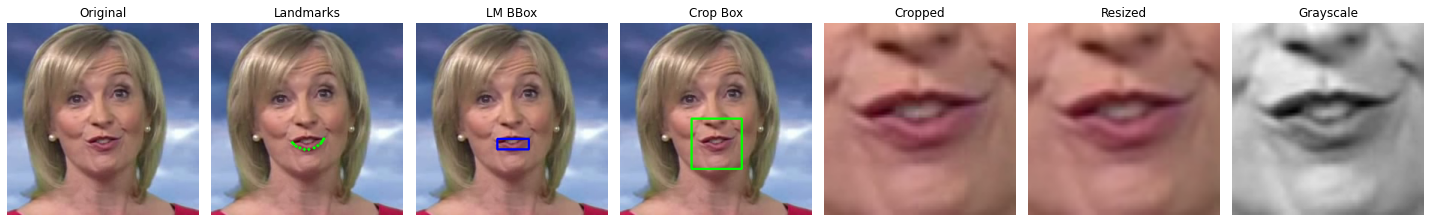


Cell 10: Visualization Complete.


In [ ]:
# Cell 10: Visualize Preprocessing Stages
print("\n--- Visualizing Preprocessing Stages ---")
if 'processed_video' not in locals() or processed_video is None:
     print("Skipping visualization as example preprocessing failed.")
elif not os.path.exists(example_video_path):
    print("Cannot visualize: Example video file path not found.")
else:
    cap = cv2.VideoCapture(example_video_path)
    if not cap.isOpened():
         print(f"Error: Could not open video file for visualization: {example_video_path}")
    else:
        total_frames_in_video = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        frame_to_visualize_idx = min(total_frames_in_video // 2, total_frames_in_video - 1)
        if frame_to_visualize_idx < 0: frame_to_visualize_idx = 0
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_to_visualize_idx)
        ret, frame = cap.read()
        cap.release()
        if not ret:
            print(f"Error: Could not read frame {frame_to_visualize_idx} for visualization.")
        else:
            print(f"Visualizing preprocessing for frame {frame_to_visualize_idx} of {example_video_path}")
            mp_face_mesh = mp.solutions.face_mesh
            with mp_face_mesh.FaceMesh(static_image_mode=True, max_num_faces=1, refine_landmarks=False, min_detection_confidence=0.5) as face_mesh:
                intermediate_results = process_frame_with_intermediates(
                    frame, face_mesh, margin=FACE_MESH_MARGIN, target_size=(IMG_WIDTH, IMG_HEIGHT)
                )
            if intermediate_results is None:
                print("Face or mouth landmarks not detected in the selected frame.")
            else:
                fig, axes = plt.subplots(1, 7, figsize=(20, 3))
                titles = ["Original", "Landmarks", "LM BBox", "Crop Box", "Cropped", "Resized", "Grayscale"]
                keys = ["original_frame_rgb", "landmarks_overlay", "original_with_box", "original_with_sq_box", "cropped_rgb", "resized_rgb", "gray"]
                cmaps = [None, None, None, None, None, None, 'gray']
                for i, ax in enumerate(axes):
                    img_data = intermediate_results[keys[i]]
                    ax.imshow(img_data, cmap=cmaps[i])
                    ax.set_title(titles[i])
                    ax.axis("off")
                plt.tight_layout()
                plt.show()
print("\nCell 10: Visualization Complete.")

Animation finished.

Cell 11: Animation Complete.


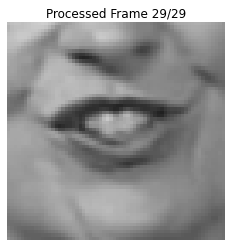

In [ ]:
# Cell 11: Animate Processed Video
print("\n--- Animating Processed Grayscale Video ---")
if 'processed_video' in locals() and processed_video is not None:
    print(f"Animating {processed_video.shape[0]} processed frames...")
    fig_anim, ax_anim = plt.subplots()
    plt.axis("off")
    vmin, vmax = np.min(processed_video), np.max(processed_video)
    im = ax_anim.imshow(processed_video[0].squeeze(), cmap='gray', vmin=vmin, vmax=vmax)
    for i in range(processed_video.shape[0]):
        im.set_data(processed_video[i].squeeze())
        ax_anim.set_title(f"Processed Frame {i+1}/{processed_video.shape[0]}")
        display(fig_anim)
        clear_output(wait=True)
        time.sleep(0.05)
    print("Animation finished.")
else:
    print("Skipping animation: 'processed_video' not found or is None.")
print("\nCell 11: Animation Complete.")

In [ ]:
# Cell 12: Gather Target Words, Create Train/Val/Test Splits, Use FULL Train Set
import json
import pickle
import numpy as np
from sklearn.model_selection import train_test_split
import collections

print("\n--- Gathering Target Word Data, Creating Splits, Using FULL Train Set ---")

# --- Define filenames ---
subset_suffix = f"_{NUM_CLASSES}words_enhanced"
save_dir = os.getcwd()
# Paths for the overall subset train/val/test splits
split_train_files_path = os.path.join(save_dir, f"lrw{subset_suffix}_split_train_files.pkl")
split_train_labels_path = os.path.join(save_dir, f"lrw{subset_suffix}_split_train_labels.pkl")
split_val_files_path = os.path.join(save_dir, f"lrw{subset_suffix}_split_val_files.pkl")
split_val_labels_path = os.path.join(save_dir, f"lrw{subset_suffix}_split_val_labels.pkl")
split_test_files_path = os.path.join(save_dir, f"lrw{subset_suffix}_split_test_files.pkl")
split_test_labels_path = os.path.join(save_dir, f"lrw{subset_suffix}_split_test_labels.pkl")
class_map_save_path = os.path.join(save_dir, f"lrw_{NUM_CLASSES}words_class_to_int_map.json")
# Paths for halves
train_h1_files_save_path = os.path.join(save_dir, f"lrw{subset_suffix}_train_h1_files.pkl")
train_h2_files_save_path = os.path.join(save_dir, f"lrw{subset_suffix}_train_h2_files.pkl")

# --- Save/Load Helpers ---
def save_list_pickle(data_list, filepath):
    try:
        with open(filepath, 'wb') as f: pickle.dump(data_list, f)
    except Exception as e: print(f"Error saving list to {filepath}: {e}")
def load_list_pickle(filepath):
    try:
        with open(filepath, 'rb') as f: return pickle.load(f)
    except: return None
def save_dict_json(data_dict, filepath):
    try:
        with open(filepath, 'w') as f: json.dump(data_dict, f, indent=4)
    except Exception as e: print(f"Error saving dict to {filepath}: {e}")
def load_dict_json(filepath):
    try:
        with open(filepath, 'r') as f: return json.load(f)
    except: return None

# --- Function get_target_files_and_labels ---
def get_target_files_and_labels(data_subset, current_lrw_root_path, target_word_list):
    subset_paths = []
    subset_labels = []
    class_map = {word: i for i, word in enumerate(sorted(target_word_list))}
    lipread_dir = os.path.join(current_lrw_root_path, "lipread_mp4")
    if not os.path.isdir(lipread_dir): print(f"Error: 'lipread_mp4' not found."); return None, None, None
    for word in tqdm(sorted(target_word_list), desc=f"Scanning {data_subset}", leave=False, disable=(data_subset != 'train')):
        label_int = class_map[word]
        word_subset_dir = os.path.join(lipread_dir, word, data_subset)
        if os.path.isdir(word_subset_dir):
            for filename in os.listdir(word_subset_dir):
                if filename.endswith(".mp4") and not filename.endswith("_mouth.mp4"):
                    subset_paths.append(os.path.join(word_subset_dir, filename))
                    subset_labels.append(label_int)
    print(f"Found {len(subset_paths)} files for '{data_subset}' set (target words).")
    return subset_paths, subset_labels, class_map

# --- Main Logic: Load or Generate Train/Val/Test Splits for Target Words ---
REGENERATE_LISTS = False # Set True to force regeneration

print("\nAttempting to load existing split data lists (train/val/test for target words)...")
train_files = load_list_pickle(split_train_files_path) if not REGENERATE_LISTS else None
train_labels = load_list_pickle(split_train_labels_path) if not REGENERATE_LISTS else None
val_files = load_list_pickle(split_val_files_path) if not REGENERATE_LISTS else None
val_labels = load_list_pickle(split_val_labels_path) if not REGENERATE_LISTS else None
test_files = load_list_pickle(split_test_files_path) if not REGENERATE_LISTS else None
test_labels = load_list_pickle(split_test_labels_path) if not REGENERATE_LISTS else None
class_to_int_map = load_dict_json(class_map_save_path) if not REGENERATE_LISTS else None

all_loaded = all(v is not None for v in [
    train_files, train_labels, val_files, val_labels, test_files, test_labels, class_to_int_map
])

if all_loaded:
    print("Successfully loaded train/val/test splits for target words from files.")
else:
    print("Could not load all necessary split data. Generating from scratch...")
    # 1. Generate/Load Class Map
    if class_to_int_map is None:
        print("Generating class map...")
        class_map = {word: i for i, word in enumerate(sorted(TARGET_WORDS))}
        if class_map: save_dict_json(class_map, class_map_save_path); class_to_int_map = class_map
        else: raise RuntimeError("Failed to create class map.")

    # 2. Gather ALL files for TARGET_WORDS
    print("Gathering all files for target words...")
    if 'lrw_root_path' not in locals(): raise NameError("lrw_root_path not defined.")
    all_files = []
    all_labels = []
    for subset in ["train", "val", "test"]:
        files, labels, _ = get_target_files_and_labels(subset, lrw_root_path, TARGET_WORDS)
        if files: all_files.extend(files); all_labels.extend(labels)
    if not all_files: raise RuntimeError("No files found for target words.")
    print(f"Gathered {len(all_files)} files for target words.")

    # 3. Split ALL data into Train/Val/Test
    print("Splitting gathered data (e.g., 80/10/10)...")
    all_labels_np = np.array(all_labels)
    VAL_SIZE = 0.10; TEST_SIZE = 0.10; TRAIN_SIZE = 1.0 - VAL_SIZE - TEST_SIZE
    split_train_files, files_temp, split_train_labels, labels_temp = train_test_split(
        all_files, all_labels_np, train_size=TRAIN_SIZE, random_state=42, stratify=all_labels_np)
    relative_test_size = TEST_SIZE / (VAL_SIZE + TEST_SIZE)
    split_val_files, split_test_files, split_val_labels, split_test_labels = train_test_split(
        files_temp, labels_temp, test_size=relative_test_size, random_state=42, stratify=labels_temp)

    # Assign to final variables and convert labels to lists
    train_files, train_labels = split_train_files, split_train_labels.tolist()
    val_files, val_labels = split_val_files, split_val_labels.tolist()
    test_files, test_labels = split_test_files, split_test_labels.tolist()
    print(f"Split complete: Train={len(train_files)}, Val={len(val_files)}, Test={len(test_files)}")

    # Save these primary splits
    print("Saving primary train/val/test splits...")
    save_list_pickle(train_files, split_train_files_path); save_list_pickle(train_labels, split_train_labels_path)
    save_list_pickle(val_files, split_val_files_path); save_list_pickle(val_labels, split_val_labels_path)
    save_list_pickle(test_files, split_test_files_path); save_list_pickle(test_labels, split_test_labels_path)

    # Optional: Remove the half-split files if they exist from previous runs
    if os.path.exists(train_h1_files_save_path): os.remove(train_h1_files_save_path)
    if os.path.exists(train_h1_labels_save_path): os.remove(train_h1_labels_save_path)
    if os.path.exists(train_h2_files_save_path): os.remove(train_h2_files_save_path)
    if os.path.exists(train_h2_labels_save_path): os.remove(train_h2_labels_save_path)

# --- Final Verification ---
if train_files: print(f"\nUsing FULL Training Set ({NUM_CLASSES} words): {len(train_files)} samples.")
if val_files: print(f"Using Validation Set ({NUM_CLASSES} words): {len(val_files)} samples.")
if test_files: print(f"Using Test Set ({NUM_CLASSES} words): {len(test_files)} samples.")
if class_to_int_map: print(f"Class mapping available with {len(class_to_int_map)} entries.")
print("\nCell 12: File Path Gathering & Splitting (Target Words, Full Train) Complete.")


--- Gathering Target Word Data, Creating Splits, Using FULL Train Set ---

Attempting to load existing split data lists (train/val/test for target words)...
Successfully loaded train/val/test splits for target words from files.

Using FULL Training Set (60 words): 52328 samples.
Using Validation Set (60 words): 6541 samples.
Using Test Set (60 words): 6542 samples.
Class mapping available with 60 entries.

Cell 12: File Path Gathering & Splitting (Target Words, Full Train) Complete.


In [ ]:

import glob

print("Checking for and removing existing cache lockfiles...")
cache_patterns_to_check = [
    f"tf_cache_train_full{subset_suffix}_aug*", # Match train cache files
    f"tf_cache_val_split{subset_suffix}*",    # Match val cache files
    f"tf_cache_test_split{subset_suffix}*"    # Match test cache files
]

files_removed = 0
for pattern in cache_patterns_to_check:
    # Specifically look for .lockfile extensions
    lockfiles = glob.glob(os.path.join(save_dir, pattern + ".lockfile"))
    for lockfile in lockfiles:
        try:
            os.remove(lockfile)
            print(f"Removed existing lockfile: {lockfile}")
            files_removed += 1
        except OSError as e:
            print(f"Error removing lockfile {lockfile}: {e}")

if files_removed > 0:
    print("Removed lingering lockfiles. Proceeding...")
else:
    print("No lingering lockfiles found.")

Checking for and removing existing cache lockfiles...
Removed existing lockfile: /home/cc/tf_cache_train_full_60words_enhanced_aug_0.lockfile
Removed lingering lockfiles. Proceeding...


In [ ]:
# Cell 13: Create TensorFlow Datasets (Using Full Train Set)
print("\n--- TensorFlow Data Pipeline Setup (Using Full Train Set) ---")
AUTOTUNE = tf.data.AUTOTUNE
output_signature = tf.TensorSpec(shape=(NUM_FRAMES, IMG_HEIGHT, IMG_WIDTH, 1), dtype=tf.uint8)
@tf.function
def tf_preprocess_video_wrapper(video_path):
    processed_video = tf.numpy_function(func=preprocess_video, inp=[video_path], Tout=tf.uint8)
    processed_video.set_shape(output_signature.shape)
    return processed_video
def load_and_normalize(path, label, augment=False):
    video = tf_preprocess_video_wrapper(path)
    video = tf.cast(video, tf.float32) / 255.0
    if augment: # Applying augmentation only during training dataset map
        video = random_flip_horizontal(video)
        video = random_brightness(video, max_delta=0.2)
    tf.debugging.check_numerics(video, message="Checking video tensor for NaNs/Infs")
    return video, tf.cast(label, tf.int32)

@tf.function
def random_flip_horizontal(video_frames):
    if tf.random.uniform(()) > 0.5: video_frames = tf.image.flip_left_right(video_frames)
    return video_frames
@tf.function
def random_brightness(video_frames, max_delta=0.2):
     adjusted_frames = tf.map_fn(lambda frame: tf.image.random_brightness(frame, max_delta=max_delta), video_frames, dtype=tf.float32)
     return tf.clip_by_value(adjusted_frames, 0.0, 1.0)
# --- Create Dataset Function (with cache filename) ---
def create_dataset(file_paths, labels, cache_filename=None, augment=False):
    if not file_paths or not labels or len(file_paths) == 0: return None
    path_ds = tf.data.Dataset.from_tensor_slices(file_paths)
    label_ds = tf.data.Dataset.from_tensor_slices(labels)
    ds = tf.data.Dataset.zip((path_ds, label_ds))
    ds = ds.map(lambda path, label: load_and_normalize(path, label, augment=augment), num_parallel_calls=AUTOTUNE)
    if cache_filename:
        cache_path = os.path.join(save_dir, cache_filename)
        print(f"Applying caching to file (post-map): {cache_path}")
        ds = ds.cache(cache_path)
    else:
        print("Applying in-memory caching (post-map).")
        ds = ds.cache()
    return ds
# --- Configure Performance Function ---
def configure_for_performance(ds, file_count, shuffle=False):
    if ds is None: return None
    if shuffle:
        buffer_size = min(file_count, 2000)
        print(f"Shuffling with buffer size: {buffer_size}")
        ds = ds.shuffle(buffer_size=buffer_size, reshuffle_each_iteration=True)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(buffer_size=AUTOTUNE)
    return ds

# Create datasets using the FULL training split and new cache names
print(f"\nCreating TRAIN dataset (Full Split - {len(train_files)} samples) with Augmentation...")
train_cache_file = f"tf_cache_train_full{subset_suffix}_aug"
train_ds_raw = create_dataset(train_files, train_labels, cache_filename=train_cache_file, augment=True)
train_ds = configure_for_performance(train_ds_raw, len(train_files), shuffle=True)

print(f"\nCreating VAL dataset ({len(val_files)} samples)...")
val_cache_file = f"tf_cache_val_split{subset_suffix}"
val_ds_raw = create_dataset(val_files, val_labels, cache_filename=val_cache_file, augment=False)
val_ds = configure_for_performance(val_ds_raw, len(val_files), shuffle=False)

print(f"\nCreating TEST dataset ({len(test_files)} samples)...")
test_cache_file = f"tf_cache_test_split{subset_suffix}"
test_ds_raw = create_dataset(test_files, test_labels, cache_filename=test_cache_file, augment=False)
test_ds = configure_for_performance(test_ds_raw, len(test_files), shuffle=False)

print("\nCell 13: Dataset Pipeline Ready (Using Full Train Set).")


--- TensorFlow Data Pipeline Setup (Using Full Train Set) ---

Creating TRAIN dataset (Full Split - 52328 samples) with Augmentation...
Applying caching to file (post-map): /home/cc/tf_cache_train_full_60words_enhanced_aug
Shuffling with buffer size: 2000

Creating VAL dataset (6541 samples)...
Applying caching to file (post-map): /home/cc/tf_cache_val_split_60words_enhanced

Creating TEST dataset (6542 samples)...
Applying caching to file (post-map): /home/cc/tf_cache_test_split_60words_enhanced

Cell 13: Dataset Pipeline Ready (Using Full Train Set).


In [ ]:
# Cell 15 (Option A: Enhanced Transformer)
print("\n--- Defining Optimized Model Architecture (Enhanced Transformer as Custom Layer) ---")

from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNetV3Small
import tensorflow as tf

# --- Layer Definitions (AttentionPooling1D, PositionalEmbedding, TransformerEncoderBlock) ---
class AttentionPooling1D(layers.Layer):
    def __init__(self, **kwargs): super().__init__(**kwargs); self.attention_dense = None
    def build(self, input_shape): self.attention_dense = layers.Dense(1, activation='tanh', name="att_pool_dense"); super().build(input_shape)
    def call(self, inputs): w_logits = self.attention_dense(inputs); w = tf.nn.softmax(w_logits, axis=1); return tf.reduce_sum(inputs * w, axis=1)
    def compute_output_shape(self, input_shape): return tf.TensorShape((input_shape[0], input_shape[-1]))
    def get_config(self): return super().get_config()

class PositionalEmbedding(layers.Layer):
    def __init__(self, sequence_length, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.pos_emb = layers.Embedding(input_dim=sequence_length, output_dim=embed_dim, name="pos_emb_layer")
        self.seq_len = sequence_length; self.vocab_size = vocab_size; self.embed_dim = embed_dim
    def call(self, x):
        L = tf.shape(x)[1]; positions = tf.range(0, L); positions = tf.minimum(positions, self.seq_len - 1)
        return x + self.pos_emb(positions)
    def get_config(self): config = super().get_config(); config.update({"sequence_length": self.seq_len, "vocab_size": self.vocab_size, "embed_dim": self.embed_dim}); return config

class TransformerEncoderBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout_rate=0.1, l2_reg=1e-4, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim; self.num_heads = num_heads; self.ff_dim = ff_dim; self.dropout_rate = dropout_rate; self.l2_reg = l2_reg
        self.mha = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim // num_heads, name="multi_head_attention")
        self.dropout1 = layers.Dropout(dropout_rate); self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.ffn_dense1 = layers.Dense(ff_dim, activation="relu", kernel_regularizer=regularizers.l2(l2_reg), name="ffn_dense1")
        self.ffn_dense2 = layers.Dense(embed_dim, kernel_regularizer=regularizers.l2(l2_reg), name="ffn_dense2")
        self.dropout2 = layers.Dropout(dropout_rate); self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
    def call(self, inputs, training=False):
        attn_output = self.mha(inputs, inputs); attn_output = self.dropout1(attn_output, training=training); x = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn_dense1(x); ffn_output = self.ffn_dense2(ffn_output); ffn_output = self.dropout2(ffn_output, training=training); x = self.layernorm2(x + ffn_output)
        return x
    def get_config(self):
        config = super().get_config(); config.update({"embed_dim": self.embed_dim, "num_heads": self.num_heads, "ff_dim": self.ff_dim, "dropout_rate": self.dropout_rate, "l2_reg": self.l2_reg}); return config

# --- Build Function (with modified parameters) ---
def build_optimized_visual_classifier(
    input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES,
    frontend_conv_filters=32, frontend_kernel_size=(5, 5, 5), frontend_strides=(1, 2, 2),
    frontend_pool_size=(1, 2, 2), frontend_pool_strides=(1, 1, 1),
    mobilenet_alpha=0.75, # Keeping MobileNetV3Small for this option
    # --- MODIFIED TRANSFORMER PARAMETERS ---
    transformer_embed_dim=128,
    num_transformer_blocks=4,
    num_transformer_heads=8,
    transformer_ff_dim=512,
    transformer_dropout=0.25,
    transformer_l2_reg=2e-4,
    # --- END MODIFICATIONS ---
    use_attention_pooling=True,
    mlp_units=[], mlp_dropout=0.3
    ):
    inputs = layers.Input(shape=input_shape, name="video_input", dtype=tf.float32)
    # --- Frontend  ---
    x = layers.Conv3D(filters=frontend_conv_filters, kernel_size=frontend_kernel_size, strides=frontend_strides, padding='same', name='frontend_conv3d')(inputs)
    x = layers.BatchNormalization(name='frontend_bn')(x)
    x = layers.Activation('relu', name='frontend_relu')(x)
    x = layers.MaxPool3D(pool_size=frontend_pool_size, strides=frontend_pool_strides, padding='same', name='frontend_maxpool3d')(x)
    x = layers.Conv3D(filters=3, kernel_size=(1, 1, 1), padding='same', activation='relu', name='channel_proj_3d')(x)
    # --- Backbone ( MobileNetV3Small) ---
    backbone_input_shape = x.shape[2:]
    mobilenet_core = MobileNetV3Small(include_top=False, weights=None, input_shape=backbone_input_shape, pooling='avg', alpha=mobilenet_alpha)
    x = layers.TimeDistributed(mobilenet_core, name='timedist_mobilenet')(x)
    # --- Temporal Projection  ---
    mobilenet_output_filters = x.shape[-1]
    if mobilenet_output_filters != transformer_embed_dim:
         x = layers.TimeDistributed(layers.Dense(transformer_embed_dim), name='feature_projection')(x)
    # --- Temporal Transformer Backend ---
    x = PositionalEmbedding(NUM_FRAMES, num_classes, transformer_embed_dim, name='positional_embedding')(x)
    x = layers.Dropout(transformer_dropout, name='pos_embedding_dropout')(x)
    for i in range(num_transformer_blocks):
        encoder_layer = TransformerEncoderBlock(
            embed_dim=transformer_embed_dim, num_heads=num_transformer_heads,
            ff_dim=transformer_ff_dim, dropout_rate=transformer_dropout,
            l2_reg=transformer_l2_reg, name=f'transformer_encoder_{i+1}'
        )
        x = encoder_layer(x)
    # --- Temporal Pooling  ---
    if use_attention_pooling: x = AttentionPooling1D(name='attention_pooling')(x)
    else: x = layers.GlobalAveragePooling1D(name='temporal_global_avg_pool')(x)
    # --- Classifier Head (Uses transformer_l2_reg) ---
    outputs = layers.Dense(
        num_classes, activation='softmax', name='classifier_output', dtype='float32',
        kernel_regularizer=regularizers.l2(transformer_l2_reg)
    )(x)
    model = Model(inputs=inputs, outputs=outputs, name="optimized_visual_classifier_enhanced_tf")
    return model

# Instantiate and summarize
tf.keras.backend.clear_session()
# Explicitly pass the modified parameters for clarity during the call
lipreading_model = build_optimized_visual_classifier(
    transformer_embed_dim=128,
    num_transformer_blocks=4,
    num_transformer_heads=8,
    transformer_ff_dim=512,
    transformer_dropout=0.25,
    transformer_l2_reg=2e-4
)
lipreading_model.summary(expand_nested=True)
print("\nCell 15 (Option A): Optimized Model Defined (Enhanced Transformer).")


--- Defining Optimized Model Architecture (Enhanced Transformer as Custom Layer) ---


Model: "optimized_visual_classifier_enhanced_tf"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ video_input (InputLayer)        │ (None, 29, 64, 64, 1)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ frontend_conv3d (Conv3D)        │ (None, 29, 32, 32, 32) │         4,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ frontend_bn                     │ (None, 29, 32, 32, 32) │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ frontend_relu (Activation)      │ (None, 29, 32, 32, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ frontend_maxpool3d              │ (None, 29, 32, 32, 32) │             0 │
│ (MaxPooling3D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ channel_proj_3d (Conv3D)        │ (None, 29, 32, 32, 3)  │            99 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ timedist_mobilenet              │ (None, 29, 432)        │       583,160 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_projection              │ (None, 29, 128)        │        55,424 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_embedding            │ (None, 29, 128)        │         3,712 │
│ (PositionalEmbedding)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pos_embedding_dropout (Dropout) │ (None, 29, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_1           │ (None, 29, 128)        │       198,272 │
│ (TransformerEncoderBlock)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_2           │ (None, 29, 128)        │       198,272 │
│ (TransformerEncoderBlock)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_3           │ (None, 29, 128)        │       198,272 │
│ (TransformerEncoderBlock)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_4           │ (None, 29, 128)        │       198,272 │
│ (TransformerEncoderBlock)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_pooling               │ (None, 128)            │             0 │
│ (AttentionPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_output (Dense)       │ (None, 60)             │         7,740 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,447,383 (5.52 MB)

 Trainable params: 1,437,639 (5.48 MB)

 Non-trainable params: 9,744 (38.06 KB)


Cell 15 (Option A): Optimized Model Defined (Enhanced Transformer).


In [ ]:
# Cell 15.1: Explicitly Build the Model
print("\n--- Explicitly Building Model ---")


try:
    dummy_input = tf.zeros((1,) + INPUT_SHAPE, dtype=tf.float32)
    print(f"Building model with dummy input shape: {dummy_input.shape}")

    _ = lipreading_model(dummy_input, training=False)
    print("Model built successfully.")
except NameError as e:
     print(f"Error: Cannot build model. Required variables (e.g., INPUT_SHAPE, lipreading_model) not defined? {e}")
except Exception as e:
    print(f"An unexpected error occurred during model build: {e}")
    import traceback
    traceback.print_exc()

print("\nCell 15.1: Build Step Complete.")


--- Explicitly Building Model ---
Building model with dummy input shape: (1, 29, 64, 64, 1)
Model built successfully.

Cell 15.1: Build Step Complete.


In [ ]:
# Cell 16 (Option A: Enhanced Transformer - CORRECTED)
print("\n--- Compiling Enhanced Transformer Model and Setting Up Callbacks ---")

import tensorflow as tf
from tensorflow.keras import losses, metrics, optimizers, callbacks
import os

# --- Optimizer  ---
initial_learning_rate = 8e-5
NUM_EPOCHS_FOR_SCHEDULE = 50

if 'train_ds' in locals() and train_ds is not None and 'BATCH_SIZE' in locals():
    try:
        # Estimate steps per epoch. Use len(train_files) as fallback if cardinality is unknown.
        if hasattr(train_ds, 'cardinality') and train_ds.cardinality() != tf.data.UNKNOWN_CARDINALITY:
             steps_per_epoch_est = train_ds.cardinality().numpy()
        elif 'train_files' in locals():
             steps_per_epoch_est = len(train_files) // BATCH_SIZE
        else:
             steps_per_epoch_est = 1 # Default if size unknown
    except:
        steps_per_epoch_est = len(train_files) // BATCH_SIZE if 'train_files' in locals() else 1

    if steps_per_epoch_est <= 0: steps_per_epoch_est = 1
    total_steps = steps_per_epoch_est * NUM_EPOCHS_FOR_SCHEDULE
    warmup_steps = steps_per_epoch_est * 2
    # Ensure warmup_steps is not greater than total_steps
    warmup_steps = min(warmup_steps, total_steps // 2) if total_steps > 0 else 0
    decay_steps = max(1, total_steps - warmup_steps)
    lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate,
        decay_steps=decay_steps,
        alpha=1e-6,
        warmup_target=initial_learning_rate,
        warmup_steps=warmup_steps
    )
    print(f"Using CosineDecay LR starting at {initial_learning_rate}")
else:
    lr_schedule = initial_learning_rate
    print(f"Using fixed LR: {initial_learning_rate} (train_ds or BATCH_SIZE not found)")


optimizer = tf.keras.optimizers.AdamW(learning_rate=lr_schedule, weight_decay=5e-5, clipnorm=1.0)
print(f"Using Optimizer: AdamW")

# --- Loss & Metrics  ---
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False)
metrics_list = [tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy')]

print(f"Using Loss: {loss_fn.name}, Metrics: {[m.name for m in metrics_list]}")


# --- Compile ---
if 'lipreading_model' in locals():
    lipreading_model.compile(optimizer=optimizer, loss=loss_fn, metrics=metrics_list)
    print("\nModel Compiled.")
else:
    print("\nERROR: lipreading_model not defined. Please run Cell 15 (Option A) first.")

# --- Callbacks  ---

if 'lrw_root_path' in locals() and 'subset_suffix' in locals():
    checkpoint_dir = os.path.join(lrw_root_path , f"training_checkpoints_tf{subset_suffix}_tf4x128")
    log_dir = os.path.join(lrw_root_path, f"logs_tf{subset_suffix}_tf4x128")
    os.makedirs(checkpoint_dir, exist_ok=True); os.makedirs(log_dir, exist_ok=True)
    print(f"\nCheckpoints directory: {checkpoint_dir}")
    print(f"TensorBoard directory: {log_dir}")

    checkpoint_filepath = os.path.join(checkpoint_dir, "ckpt-epoch_{epoch:02d}-val_acc_{val_accuracy:.3f}.weights.h5")
    model_checkpoint_callback = callbacks.ModelCheckpoint(filepath=checkpoint_filepath, monitor='val_accuracy', mode='max', save_best_only=True, save_weights_only=True, verbose=1)
    tensorboard_callback = callbacks.TensorBoard(log_dir=log_dir, histogram_freq=0, write_graph=False, update_freq='epoch')

    early_stopping_callback = callbacks.EarlyStopping(monitor='val_accuracy', patience=18, verbose=1, mode='max', restore_best_weights=True)

    training_callbacks = [model_checkpoint_callback, tensorboard_callback, early_stopping_callback]
    print("\nCell 16 (Option A): Callbacks Configured for Enhanced Transformer Run.")
else:
    print("\nERROR: Cannot configure callbacks. 'lrw_root_path' or 'subset_suffix' not defined.")


--- Compiling Enhanced Transformer Model and Setting Up Callbacks ---
Using CosineDecay LR starting at 8e-05
Using Optimizer: AdamW
Using Loss: sparse_categorical_crossentropy, Metrics: ['accuracy']

Model Compiled.

Checkpoints directory: /home/cc/training_checkpoints_tf_60words_enhanced_tf4x128
TensorBoard directory: /home/cc/logs_tf_60words_enhanced_tf4x128

Cell 16 (Option A): Callbacks Configured for Enhanced Transformer Run.


In [ ]:
# Cell 17: Train the Optimized Model (Add glob Import)
print("\n--- Starting Optimized Model Training ---")

import glob
import time
import matplotlib.pyplot as plt
import tensorflow as tf

# --- Training Hyperparameters ---
NUM_EPOCHS = 70
resume_from_epoch = 0

class EpochBatchLogger(tf.keras.callbacks.Callback):
    def on_epoch_begin(self, epoch, logs=None): print(f"\n--- Starting Epoch {epoch + 1}/{NUM_EPOCHS} ---")

# Check if datasets and checkpoint directory are defined
if ('train_ds' in locals() and 'val_ds' in locals() and train_ds is not None and val_ds is not None and
    'lipreading_model' in locals() and 'training_callbacks' in locals() and 'checkpoint_dir' in locals()):

    print(f"Training for {NUM_EPOCHS} epochs...")
    try: print(f"Train batches: {train_ds.cardinality().numpy()}, Val batches: {val_ds.cardinality().numpy()}")
    except: print("Could not determine dataset cardinality.")

    # --- Checkpoint loading logic ---
    # Make sure checkpoint_dir exists before globbing
    if not os.path.exists(checkpoint_dir):
         print(f"Checkpoint directory does not exist: {checkpoint_dir}")
         print("Starting fresh training.")
    else:
        checkpoint_pattern = os.path.join(checkpoint_dir, f"ckpt-epoch_{resume_from_epoch:02d}-val_acc_*.weights.h5")
        matching_checkpoints = glob.glob(checkpoint_pattern)
        if matching_checkpoints and resume_from_epoch > 0:

            checkpoint_path = matching_checkpoints[0] # Assume first match is okay
            print(f"Attempting to resume from checkpoint: {checkpoint_path}")
            try:
                lipreading_model.load_weights(checkpoint_path)
                print("Resuming training...")
            except Exception as e:
                print(f"Warning: Error loading weights from {checkpoint_path}: {e}. Starting fresh.")
                resume_from_epoch = 0 # Reset epoch if loading failed
        else:
            if resume_from_epoch > 0:
                print(f"Warning: No checkpoint found matching pattern for epoch {resume_from_epoch}. Starting fresh.")
            else:
                print("Starting fresh training.")

    start_train_time = time.time()
    # Add logger callback if it wasn't already added
    if not any(isinstance(cb, EpochBatchLogger) for cb in training_callbacks):
         training_callbacks.append(EpochBatchLogger())

    # --- Start Training ---
    history = lipreading_model.fit(
        train_ds,
        epochs=NUM_EPOCHS,
        validation_data=val_ds,
        callbacks=training_callbacks,
        verbose=1,
        initial_epoch=resume_from_epoch
    )
    end_train_time = time.time()
    print(f"\nTraining finished in {(end_train_time - start_train_time) / 60:.2f} minutes.")

    # --- Plot ---
    if history and history.history:
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1); plt.plot(history.history['accuracy'], label='Train Acc'); plt.plot(history.history['val_accuracy'], label='Val Acc'); plt.title('Accuracy'); plt.grid(True); plt.legend()
        plt.subplot(1, 2, 2); plt.plot(history.history['loss'], label='Train Loss'); plt.plot(history.history['val_loss'], label='Val Loss'); plt.title('Loss'); plt.grid(True); plt.legend()
        plt.tight_layout(); plt.show()
        print(f"Best Validation Accuracy: {max(history.history.get('val_accuracy', [0])):.4f}")
else:
    print("Error: Essential variables (train_ds, val_ds, lipreading_model, training_callbacks, checkpoint_dir) not defined. Cannot start training.")
print("\nCell 17: Training Run Complete.")

In [ ]:
# Cell 18: Evaluate and Predict

import numpy as np
import json
import os
from tqdm import tqdm

# --- Load Best Weights ---
best_checkpoint_path = None; highest_acc = -1.0

if 'checkpoint_dir' in locals() and os.path.exists(checkpoint_dir):
    for filename in os.listdir(checkpoint_dir):
        if filename.endswith(".weights.h5") and "val_acc" in filename:
             try:
                 acc = float(filename.split('val_acc_')[-1].split('.weights.h5')[0])
                 if acc > highest_acc: highest_acc = acc; best_checkpoint_path = os.path.join(checkpoint_dir, filename)
             except: continue
if best_checkpoint_path:
    print(f"Loading best weights from: {best_checkpoint_path} (Val Acc: {highest_acc:.4f})")
    try:
        # Ensure lipreading_model exists
        if 'lipreading_model' in locals():
            lipreading_model.load_weights(best_checkpoint_path)
        else:
            print("Error: lipreading_model not defined before loading weights.")
            best_checkpoint_path = None
    except Exception as e:
        print(f"Error loading weights: {e}")
        best_checkpoint_path = None
else:
    print("Warning: No best checkpoint found or checkpoint_dir missing. Using model's current weights (if available).")

    if 'lipreading_model' not in locals():
         print("ERROR: Cannot proceed without a defined lipreading_model.")
         best_checkpoint_path = None

# --- Evaluate on Test Set ---
test_accuracy = None
if 'test_ds' in locals() and test_ds is not None and 'lipreading_model' in locals() and best_checkpoint_path is not None:
    print("\nEvaluating on Test Set...")
    try:
        test_loss, test_accuracy = lipreading_model.evaluate(test_ds, verbose=1)
        print(f"Test Loss: {test_loss:.4f}")
        print(f"Test Accuracy: {test_accuracy:.4f}")
    except Exception as e:
        print(f"Error during evaluation: {e}")
        test_accuracy = None # Mark evaluation as failed
elif 'lipreading_model' not in locals() or best_checkpoint_path is None:
     print("Skipping evaluation: Model or best weights not available.")
else:
    print("Skipping evaluation: Test dataset ('test_ds') not available.")


# --- Generate Predictions and True Labels for the ENTIRE Test Set ---
y_true_full = []
y_pred_full = []
y_pred_prob_full = None
predictions_available_full = False # Flag

if 'test_ds' in locals() and test_ds is not None and 'lipreading_model' in locals() and best_checkpoint_path is not None:
    print("\nGenerating predictions for the entire test set (for Confusion Matrix & Report)...")
    try:
        y_pred_prob_list = [] # Collect probability arrays

        for videos, labels in tqdm(test_ds, desc="Predicting on Test Set"):
            y_true_full.extend(labels.numpy())
            # Predict batch by batch and store probabilities
            batch_pred_prob = lipreading_model.predict(videos, verbose=0)
            y_pred_prob_list.append(batch_pred_prob)

        # Concatenate probabilities after iterating through all batches
        if y_pred_prob_list:
            y_pred_prob_full = np.concatenate(y_pred_prob_list, axis=0)
            y_pred_full = np.argmax(y_pred_prob_full, axis=-1)
            y_true_full = np.array(y_true_full) # Ensure y_true is a numpy array
            print(f"Predictions generated for {len(y_true_full)} test samples.")
            predictions_available_full = True
        else:
             print("Prediction failed: No batches processed from test_ds.")

    except Exception as e:
        print(f"Error generating full test set predictions: {e}")
        predictions_available_full = False
else:
    print("Skipping full test set prediction: Test dataset or model/weights not available.")


# --- Predict on a SINGLE Test Batch (for quick check - optional now) ---
if predictions_available_full: # Only show batch prediction if full prediction worked
    print("\n--- Sample Predictions vs True Labels (First Test Batch) ---")
    test_video_batch, test_label_batch = next(iter(test_ds))
    preds_prob_batch = y_pred_prob_full[:len(test_label_batch)]
    preds_idx_batch = y_pred_full[:len(test_label_batch)]
    true_idx_batch = y_true_full[:len(test_label_batch)]

    # --- Interpret Batch ---
    # Ensure class_to_int_map is loaded
    if 'class_to_int_map' not in locals() or class_to_int_map is None:
         if 'lrw_root_path' in locals() and 'NUM_CLASSES' in locals():
              class_map_save_path = os.path.join(lrw_root_path, f"lrw_{NUM_CLASSES}words_class_to_int_map.json")
              class_to_int_map = load_dict_json(class_map_save_path) # Define load_dict_json if needed
              if class_to_int_map is None: print("Warning: Failed to load class map for interpretation.")
         else: print("Warning: Cannot load class map, lrw_root_path or NUM_CLASSES missing.")

    if 'class_to_int_map' in locals() and class_to_int_map is not None:
        int_to_class_map = {v: k for k, v in class_to_int_map.items()}
        for i in range(min(10, len(true_idx_batch))): # Show first 10 of the batch
            true_word = int_to_class_map.get(true_idx_batch[i], "UNK")
            pred_word = int_to_class_map.get(preds_idx_batch[i], "UNK")
            conf = preds_prob_batch[i][preds_idx_batch[i]] * 100
            correct = "CORRECT" if true_idx_batch[i] == preds_idx_batch[i] else "WRONG"
            print(f"Sample {i+1}: True='{true_word}', Pred='{pred_word}' | Conf: {conf:.1f}% | [{correct}]")
    else:
        print("Cannot display batch sample words: Class map not available.")
#     print("\nSkipping single batch prediction display.")

print("\nCell 18: Evaluation and Prediction Data Generation Complete.")

Loading best weights from: /home/cc/training_checkpoints_tf_60words_enhanced_tf4x128/ckpt-epoch_67-val_acc_0.700.weights.h5 (Val Acc: 0.7000)

Evaluating on Test Set...


I0000 00:00:1745117089.816020 1317608 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1745117089.892550 1317788 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 560.35.03), renderer: Quadro RTX 6000/PCIe/SSE2
W0000 00:00:1745117089.906289 1317664 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1745117089.937165 1317597 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
W0000 00:00:1745117089.937791 1317677 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1745117089.995172 1318063 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 560.35.03), renderer: Quadro RTX 6000/PCIe/SSE2
W0000 00:00:1745117090.008652 1317933 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature i

  1/205 ━━━━━━━━━━━━━━━━━━━━ 40:52 12s/step - accuracy: 0.4688 - loss: 1.5936

I0000 00:00:1745117101.655036 1317592 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1745117101.726804 1323036 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 560.35.03), renderer: Quadro RTX 6000/PCIe/SSE2
W0000 00:00:1745117101.739629 1323000 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1745117101.768311 1323008 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1745117102.126158 1317573 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1745117102.198411 1323103 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 560.35.03), renderer: Quadro RTX 6000/PCIe/SSE2
W0000 00:00:1745117102.210610 1323060 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature i

  2/205 ━━━━━━━━━━━━━━━━━━━━ 12:27 4s/step - accuracy: 0.5078 - loss: 1.5707 

...

204/205 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.6955 - loss: 1.2261 

2025-04-20 03:03:09.667991: W tensorflow/core/kernels/data/cache_dataset_ops.cc:333] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


205/205 ━━━━━━━━━━━━━━━━━━━━ 1130s 5s/step - accuracy: 0.6955 - loss: 1.2260
Test Loss: 1.2127
Test Accuracy: 0.7007

Generating predictions for the entire test set (for Confusion Matrix & Report)...


Predicting on Test Set: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 205/205 [02:19<00:00,  1.47it/s]

Predictions generated for 6542 test samples.

--- Sample Predictions vs True Labels (First Test Batch) ---
Sample 1: True='AFTER', Pred='AFTER' | Conf: 77.5% | [CORRECT]
Sample 2: True='STATE', Pred='SECOND' | Conf: 72.5% | [WRONG]
Sample 3: True='SAYING', Pred='SAYING' | Conf: 93.2% | [CORRECT]
Sample 4: True='LITTLE', Pred='GETTING' | Conf: 84.3% | [WRONG]
Sample 5: True='BECAUSE', Pred='BECAUSE' | Conf: 73.9% | [CORRECT]
Sample 6: True='BEING', Pred='MEANS' | Conf: 47.7% | [WRONG]
Sample 7: True='REALLY', Pred='REALLY' | Conf: 40.1% | [CORRECT]
Sample 8: True='QUITE', Pred='GOING' | Conf: 28.2% | [WRONG]
Sample 9: True='GETTING', Pred='ANYTHING' | Conf: 75.3% | [WRONG]
Sample 10: True='LONGER', Pred='OTHER' | Conf: 53.1% | [WRONG]

Cell 18: Evaluation and Prediction Data Generation Complete.



--- Attempting to Restore Variables for Plotting (Option A Run) ---
INFO: This cell reloads data lists, class maps, and rebuilds the model architecture.
IMPORTANT: Ensure parameters below MATCH the 'Enhanced Transformer' training run.

Verifying parameters (These should match Option A run)...
Working directory set to: /home/cc
NUM_CLASSES: 60
INPUT_SHAPE: (29, 64, 64, 1)
Using architecture parameters for: Enhanced Transformer (Option A)
Expecting checkpoints in: /home/cc/training_checkpoints_tf_60words_enhanced_tf4x128
Expecting test cache file starting with: tf_cache_test_split_60words_enhanced
Expecting test list file: lrw_60words_enhanced_split_test_files.pkl

Loading class map and test file lists...
Class map (60 entries) and test lists (6542 files) loaded.

Attempting to recreate test dataset from cache...
Found cache index file: /home/cc/tf_cache_test_split_60words_enhanced.index
Successfully recreated test_ds from cache.

Re-defining model architecture (Option A)...
Rebuilding 

Predicting on Test Set: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 103/103 [02:02<00:00,  1.19s/it]


Predictions generated for 6542 test samples.

Plotting Confusion Matrix...


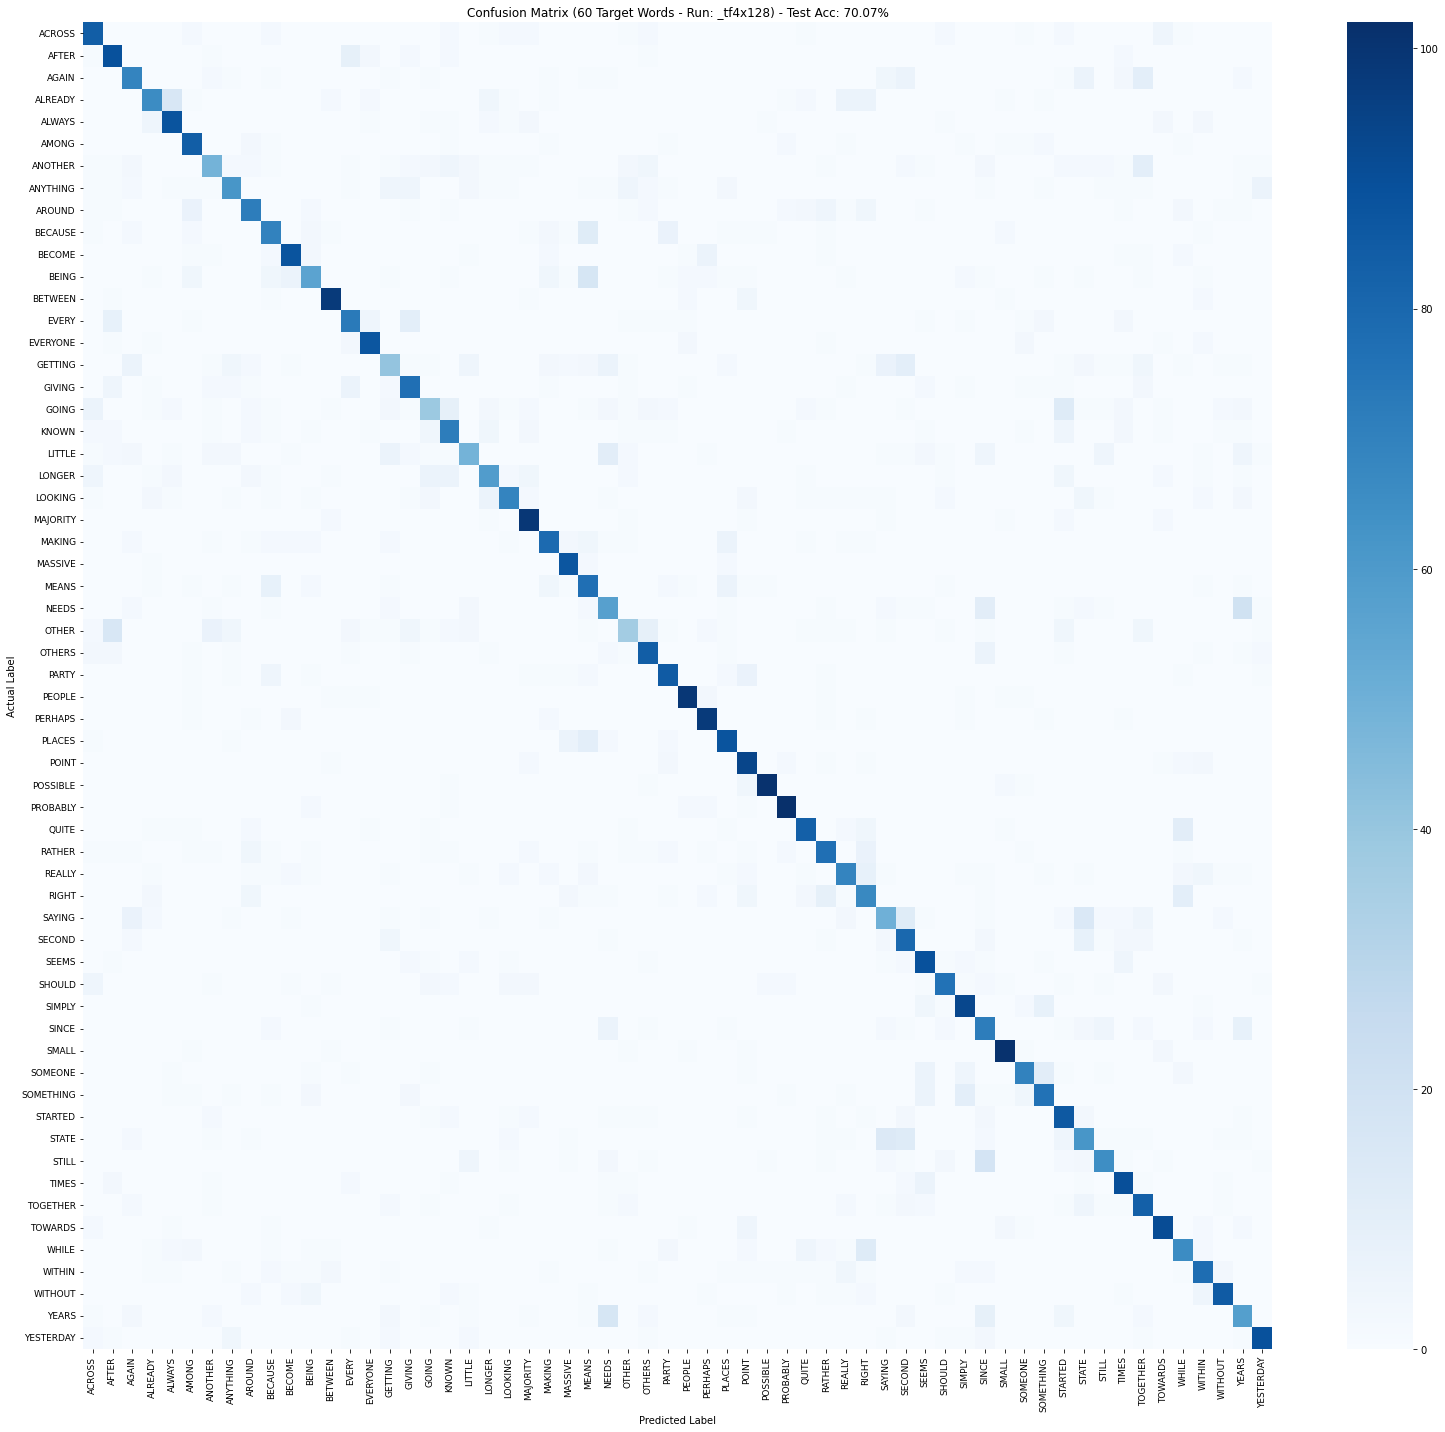


Generating Classification Report...

Classification Report (Test Set):
               precision    recall  f1-score   support

      ACROSS      0.694     0.764     0.727       110
       AFTER      0.654     0.809     0.724       110
       AGAIN      0.651     0.627     0.639       110
     ALREADY      0.733     0.600     0.660       110
      ALWAYS      0.739     0.800     0.769       110
       AMONG      0.730     0.840     0.781       100
     ANOTHER      0.613     0.445     0.516       110
    ANYTHING      0.689     0.564     0.620       110
      AROUND      0.699     0.655     0.676       110
     BECAUSE      0.631     0.636     0.633       110
      BECOME      0.815     0.800     0.807       110
       BEING      0.651     0.509     0.571       110
     BETWEEN      0.867     0.891     0.879       110
       EVERY      0.716     0.664     0.689       110
    EVERYONE      0.853     0.853     0.853       102
     GETTING      0.506     0.373     0.429       110
      GI

In [ ]:
# Cell 19: Restore Variables for Plotting (Option A - Enhanced Transformer Run)
print("\n--- Attempting to Restore Variables for Plotting (Option A Run) ---")
print("INFO: This cell reloads data lists, class maps, and rebuilds the model architecture.")
print("IMPORTANT: Ensure parameters below MATCH the 'Enhanced Transformer' training run.")

# === 1. Imports ===
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks
from tensorflow.keras.applications import MobileNetV3Small, MobileNetV3Large # Import both just in case
from tensorflow.keras.models import Model
import numpy as np
import json
import pickle
import os
import glob
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report


# === 2. Define/Verify Key Parameters (MATCHING OPTION A RUN) ===
print("\nVerifying parameters (These should match Option A run)...")
try:
    # --- Core Paths and Settings ---
    lrw_root_path = "/home/cc" # Or os.getcwd() if set earlier and still valid
    os.chdir(lrw_root_path) # Go to the working directory
    print(f"Working directory set to: {os.getcwd()}")

    # --- Target Word/Class Settings ---
    TARGET_WORDS = [ # PASTE THE *EXACT* LIST USED FOR TRAINING HERE (Should be the 60 words)
        "AFTER", "AGAIN", "ALREADY", "ALWAYS", "AMONG", "ACROSS", "PEOPLE", "YEARS",
        "TIMES", "BEING", "BETWEEN", "EVERY", "EVERYONE", "SOMETHING", "SOMEONE",
        "STILL", "WHILE", "WITHIN", "WITHOUT", "TOGETHER", "TOWARDS", "OTHER", "OTHERS",
        "ANOTHER", "ANYTHING", "AROUND", "BECAUSE", "BECOME", "GETTING", "GIVING", "GOING",
        "KNOWN", "LITTLE", "LONGER", "LOOKING", "MAKING", "MAJORITY", "MEANS", "MASSIVE",
        "NEEDS", "PARTY", "PERHAPS", "PLACES", "POINT", "POSSIBLE", "PROBABLY", "QUITE",
        "RATHER", "REALLY", "RIGHT", "SAYING", "SECOND", "SEEMS", "SHOULD", "SIMPLY",
        "SINCE", "SMALL", "STARTED", "STATE", "YESTERDAY"
    ]
    TARGET_WORDS = sorted(list(set(TARGET_WORDS)))
    NUM_CLASSES = len(TARGET_WORDS)
    print(f"NUM_CLASSES: {NUM_CLASSES}")

    # --- Data/Input Parameters ---
    BATCH_SIZE = 64 # Must match dataset cache batch size
    IMG_WIDTH = 64
    IMG_HEIGHT = 64
    NUM_FRAMES = 29
    GRAYSCALE = True
    INPUT_SHAPE = (NUM_FRAMES, IMG_HEIGHT, IMG_WIDTH, 1 if GRAYSCALE else 3)
    print(f"INPUT_SHAPE: {INPUT_SHAPE}")

    # --- Model Architecture Parameters (Option A - Enhanced Transformer) ---
    experiment_suffix = "_tf4x128" # From Cell 16 Option A
    FRONTEND_CONV_FILTERS=32; FRONTEND_KERNEL_SIZE=(5, 5, 5); FRONTEND_STRIDES=(1, 2, 2); FRONTEND_POOL_SIZE=(1, 2, 2); FRONTEND_POOL_STRIDES=(1, 1, 1); MOBILENET_ALPHA=0.75; USE_MOBILENET_LARGE=False; # Keeping MobileNet Small for Option A
    TRANSFORMER_EMBED_DIM=128; NUM_TRANSFORMER_BLOCKS=4; NUM_TRANSFORMER_HEADS=8; TRANSFORMER_FF_DIM=512; TRANSFORMER_DROPOUT=0.25; TRANSFORMER_L2_REG=2e-4; USE_ATTENTION_POOLING=True
    print("Using architecture parameters for: Enhanced Transformer (Option A)")

    # --- Determine Checkpoint/Log/Cache Paths ---

    data_list_subset_suffix = f"_{NUM_CLASSES}words_enhanced"
    cache_subset_suffix = f"_{NUM_CLASSES}words_enhanced"
    checkpoint_log_subset_suffix = f"_{NUM_CLASSES}words_enhanced"
    save_dir = lrw_root_path
    checkpoint_dir = os.path.join(save_dir , f"training_checkpoints_tf{checkpoint_log_subset_suffix}{experiment_suffix}")
    test_cache_filename = f"tf_cache_test_split{cache_subset_suffix}"
    class_map_filename = f"lrw_{NUM_CLASSES}words_class_to_int_map.json"
    test_files_list_filename = f"lrw{data_list_subset_suffix}_split_test_files.pkl"
    test_labels_list_filename = f"lrw{data_list_subset_suffix}_split_test_labels.pkl"

    print(f"Expecting checkpoints in: {checkpoint_dir}")
    print(f"Expecting test cache file starting with: {test_cache_filename}")
    print(f"Expecting test list file: {test_files_list_filename}")

    params_ok = True
except Exception as e:
    print(f"Error setting up parameters: {e}")
    params_ok = False

if params_ok:
    # === 3. Helper Functions (Save/Load & Preprocessing Wrapper) ===
    def load_list_pickle(filepath):
        try:
            with open(filepath, 'rb') as f: return pickle.load(f)
        except Exception as e:
            print(f"Error loading pickle {filepath}: {e}")
            return None
    def load_dict_json(filepath):
        try:
            with open(filepath, 'r') as f: return json.load(f)
        except Exception as e:
            print(f"Error loading json {filepath}: {e}")
            return None

    # Need the basic structure of the wrapper for TF dataset mapping
    output_signature_restore = tf.TensorSpec(shape=(NUM_FRAMES, IMG_HEIGHT, IMG_WIDTH, 1), dtype=tf.uint8)
    @tf.function
    def tf_preprocess_video_wrapper_restore(video_path):
         return tf.zeros(output_signature_restore.shape, dtype=output_signature_restore.dtype)

    def load_and_normalize_restore(path, label):

         video = tf_preprocess_video_wrapper_restore(path)
         video = tf.cast(video, tf.float32) / 255.0
         return video, tf.cast(label, tf.int32)


    # === 4. Load Class Map and Test File Lists ===
    print("\nLoading class map and test file lists...")
    class_map_save_path = os.path.join(save_dir, class_map_filename)
    class_to_int_map = load_dict_json(class_map_save_path)

    split_test_files_path = os.path.join(save_dir, test_files_list_filename)
    split_test_labels_path = os.path.join(save_dir, test_labels_list_filename)
    test_files = load_list_pickle(split_test_files_path)
    test_labels = load_list_pickle(split_test_labels_path)

    if not all([class_to_int_map, test_files, test_labels]):
        print("Error: Failed to load class map or test file lists. Cannot proceed.")
        load_ok = False
    else:
        print(f"Class map ({len(class_to_int_map)} entries) and test lists ({len(test_files)} files) loaded.")
        int_to_class_map = {v: k for k, v in class_to_int_map.items()} # Create inverse map
        class_names = [int_to_class_map[i] for i in range(NUM_CLASSES)] # Get ordered class names
        load_ok = True

if params_ok and load_ok:
    # === 5. Recreate Test Dataset from Cache ===
    print("\nAttempting to recreate test dataset from cache...")
    AUTOTUNE = tf.data.AUTOTUNE
    test_ds = None
    dataset_ok = False
    test_cache_path = os.path.join(save_dir, test_cache_filename)
    # Check if cache *index* file exists as a proxy for the cache
    if os.path.exists(test_cache_path + ".index"):
        print(f"Found cache index file: {test_cache_path}.index")
        try:
            # Define pipeline structure used *before* caching in Cell 13
            path_ds_dummy = tf.data.Dataset.from_tensor_slices(test_files)
            label_ds_dummy = tf.data.Dataset.from_tensor_slices(test_labels)
            ds_dummy = tf.data.Dataset.zip((path_ds_dummy, label_ds_dummy))
            ds_to_cache = ds_dummy.map(lambda path, label: load_and_normalize_restore(path, label),
                                       num_parallel_calls=AUTOTUNE)

            test_ds_raw_cached = ds_to_cache.cache(test_cache_path)

            def configure_for_performance(ds, file_count, shuffle=False):
                if ds is None: return None
                ds = ds.batch(BATCH_SIZE)
                ds = ds.prefetch(buffer_size=AUTOTUNE)
                return ds

            test_ds = configure_for_performance(test_ds_raw_cached, len(test_files), shuffle=False)

            _ = next(iter(test_ds))
            print("Successfully recreated test_ds from cache.")
            dataset_ok = True

        except Exception as e:
            print(f"Warning: Failed to load test_ds from cache ({e}). Cannot proceed with evaluation/prediction.")
            test_ds = None
            dataset_ok = False
    else:
        print(f"Error: Test dataset cache file not found at {test_cache_path}.index. Cannot evaluate/predict.")
        dataset_ok = False

if params_ok and load_ok and dataset_ok:
    # === 6. Re-define Model Architecture  ===
    print("\nRe-defining model architecture (Option A)...")
    # --- Layer Definitions  ---
    class AttentionPooling1D(layers.Layer):
        def __init__(self, **kwargs): super().__init__(**kwargs); self.attention_dense = None
        def build(self, input_shape): self.attention_dense = layers.Dense(1, activation='tanh', name="att_pool_dense"); super().build(input_shape)
        def call(self, inputs): w_logits = self.attention_dense(inputs); w = tf.nn.softmax(w_logits, axis=1); return tf.reduce_sum(inputs * w, axis=1)
        def compute_output_shape(self, input_shape): return tf.TensorShape((input_shape[0], input_shape[-1]))
        def get_config(self): return super().get_config()

    class PositionalEmbedding(layers.Layer):
        def __init__(self, sequence_length, vocab_size, embed_dim, **kwargs):
            super().__init__(**kwargs)
            self.pos_emb = layers.Embedding(input_dim=sequence_length, output_dim=embed_dim, name="pos_emb_layer")
            self.seq_len = sequence_length; self.vocab_size = vocab_size; self.embed_dim = embed_dim
        def call(self, x):
            L = tf.shape(x)[1]; positions = tf.range(0, L); positions = tf.minimum(positions, self.seq_len - 1)
            return x + self.pos_emb(positions)
        def get_config(self): config = super().get_config(); config.update({"sequence_length": self.seq_len, "vocab_size": self.vocab_size, "embed_dim": self.embed_dim}); return config

    class TransformerEncoderBlock(layers.Layer):
        def __init__(self, embed_dim, num_heads, ff_dim, dropout_rate=0.1, l2_reg=1e-4, **kwargs):
            super().__init__(**kwargs)
            self.embed_dim = embed_dim; self.num_heads = num_heads; self.ff_dim = ff_dim; self.dropout_rate = dropout_rate; self.l2_reg = l2_reg
            self.mha = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim // num_heads, name="multi_head_attention")
            self.dropout1 = layers.Dropout(dropout_rate); self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
            self.ffn_dense1 = layers.Dense(ff_dim, activation="relu", kernel_regularizer=regularizers.l2(l2_reg), name="ffn_dense1")
            self.ffn_dense2 = layers.Dense(embed_dim, kernel_regularizer=regularizers.l2(l2_reg), name="ffn_dense2")
            self.dropout2 = layers.Dropout(dropout_rate); self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        def call(self, inputs, training=False): # Ensure training flag is present
            attn_output = self.mha(inputs, inputs); attn_output = self.dropout1(attn_output, training=training); x = self.layernorm1(inputs + attn_output)
            ffn_output = self.ffn_dense1(x); ffn_output = self.ffn_dense2(ffn_output); ffn_output = self.dropout2(ffn_output, training=training); x = self.layernorm2(x + ffn_output)
            return x
        def get_config(self):
            config = super().get_config(); config.update({"embed_dim": self.embed_dim, "num_heads": self.num_heads, "ff_dim": self.ff_dim, "dropout_rate": self.dropout_rate, "l2_reg": self.l2_reg}); return config

    # --- Build Function  ---
    def build_optimized_visual_classifier(
        input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES,
        frontend_conv_filters=FRONTEND_CONV_FILTERS, frontend_kernel_size=FRONTEND_KERNEL_SIZE,
        frontend_strides=FRONTEND_STRIDES, frontend_pool_size=FRONTEND_POOL_SIZE,
        frontend_pool_strides=FRONTEND_POOL_STRIDES, mobilenet_alpha=MOBILENET_ALPHA,
        transformer_embed_dim=TRANSFORMER_EMBED_DIM, num_transformer_blocks=NUM_TRANSFORMER_BLOCKS,
        num_transformer_heads=NUM_TRANSFORMER_HEADS, transformer_ff_dim=TRANSFORMER_FF_DIM,
        transformer_dropout=TRANSFORMER_DROPOUT, transformer_l2_reg=TRANSFORMER_L2_REG,
        use_attention_pooling=USE_ATTENTION_POOLING,
        mlp_units=[], mlp_dropout=0.3
        ):
        inputs = layers.Input(shape=input_shape, name="video_input", dtype=tf.float32)
        x = layers.Conv3D(filters=frontend_conv_filters, kernel_size=frontend_kernel_size, strides=frontend_strides, padding='same', name='frontend_conv3d')(inputs)
        x = layers.BatchNormalization(name='frontend_bn')(x)
        x = layers.Activation('relu', name='frontend_relu')(x)
        x = layers.MaxPool3D(pool_size=frontend_pool_size, strides=frontend_pool_strides, padding='same', name='frontend_maxpool3d')(x)
        x = layers.Conv3D(filters=3, kernel_size=(1, 1, 1), padding='same', activation='relu', name='channel_proj_3d')(x)

        backbone_input_shape = x.shape[2:]
        # Option A used MobileNetV3Small
        mobilenet_core = MobileNetV3Small(include_top=False, weights=None, input_shape=backbone_input_shape, pooling='avg', alpha=mobilenet_alpha)
        x = layers.TimeDistributed(mobilenet_core, name='timedist_mobilenet')(x)

        mobilenet_output_filters = x.shape[-1]
        if mobilenet_output_filters != transformer_embed_dim:
             x = layers.TimeDistributed(layers.Dense(transformer_embed_dim), name='feature_projection')(x)

        x = PositionalEmbedding(NUM_FRAMES, num_classes, transformer_embed_dim, name='positional_embedding')(x)
        x = layers.Dropout(transformer_dropout, name='pos_embedding_dropout')(x)
        for i in range(num_transformer_blocks):
            encoder_layer = TransformerEncoderBlock(
                embed_dim=transformer_embed_dim, num_heads=num_transformer_heads,
                ff_dim=transformer_ff_dim, dropout_rate=transformer_dropout,
                l2_reg=transformer_l2_reg, name=f'transformer_encoder_{i+1}'
            )
            x = encoder_layer(x, training=False)

        if use_attention_pooling: x = AttentionPooling1D(name='attention_pooling')(x)
        else: x = layers.GlobalAveragePooling1D(name='temporal_global_avg_pool')(x)

        outputs = layers.Dense(
            num_classes, activation='softmax', name='classifier_output', dtype='float32',
            kernel_regularizer=regularizers.l2(transformer_l2_reg)
        )(x)
        model_name = f"restored_model{experiment_suffix.replace('_','-')}"
        model = Model(inputs=inputs, outputs=outputs, name=model_name)
        return model

    # === 7. Rebuild and Load Weights ===
    print("Rebuilding model...")
    tf.keras.backend.clear_session()
    try:
        lipreading_model = build_optimized_visual_classifier()
        dummy_input_restore = tf.zeros((1,) + INPUT_SHAPE, dtype=tf.float32)
        _ = lipreading_model(dummy_input_restore, training=False)
        print("Model rebuilt successfully.")
        model_rebuilt = True
    except Exception as e:
        print(f"Error rebuilding model: {e}")
        model_rebuilt = False

    best_checkpoint_path = None
    highest_acc = -1.0
    weights_loaded = False
    if model_rebuilt:
        print("\nFinding and loading best checkpoint weights...")
        if os.path.exists(checkpoint_dir):
            checkpoint_files = glob.glob(os.path.join(checkpoint_dir, "ckpt-epoch_*.weights.h5"))
            if not checkpoint_files:
                 print(f"Warning: No checkpoint files found in {checkpoint_dir}")
            else:
                for filename in checkpoint_files:
                    if "val_acc" in filename:
                        try:
                            acc_str = filename.split('val_acc_')[-1].split('.weights.h5')[0]
                            acc = float(acc_str)
                            if acc > highest_acc:
                                highest_acc = acc
                                best_checkpoint_path = filename
                        except: continue

                if best_checkpoint_path:
                    print(f"Loading best weights from: {best_checkpoint_path} (Val Acc: {highest_acc:.4f})")
                    try:
                        lipreading_model.load_weights(best_checkpoint_path)
                        print("Best weights loaded successfully.")
                        weights_loaded = True
                    except Exception as e:
                        print(f"Error loading weights from {best_checkpoint_path}: {e}. Might be architecture mismatch.")

                        try:
                            print("Attempting to load weights by name...")
                            lipreading_model.load_weights(best_checkpoint_path, by_name=True, skip_mismatch=True)
                            print("Loaded weights by name (check warnings for mismatches).")
                            weights_loaded = True
                        except Exception as e2:
                            print(f"Error loading weights by name either: {e2}")

                else:
                    print("Warning: No checkpoint file with 'val_acc' found in the name.")
        else:
            print(f"Error: Checkpoint directory not found: {checkpoint_dir}")

    # === 8. Evaluate and Predict (if weights loaded and dataset ready) ===
    test_loss = None
    test_accuracy = None
    predictions_available_full = False
    y_true_full = []
    y_pred_full = []

    if weights_loaded and dataset_ok:
        print("\nEvaluating on loaded Test Set...")
        try:
            lipreading_model.compile(metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy')])
            eval_results = lipreading_model.evaluate(test_ds, verbose=1, return_dict=True)
            test_accuracy = eval_results.get('accuracy')
            test_loss = eval_results.get('loss')
            if test_loss is not None: print(f"Test Loss: {test_loss:.4f}")
            if test_accuracy is not None: print(f"Test Accuracy: {test_accuracy:.4f}")
            else: print("Test accuracy could not be determined from evaluation results.")

        except Exception as e:
            print(f"Error during evaluation: {e}")
            test_accuracy = None

        print("\nGenerating predictions on loaded Test Set...")
        try:
            y_pred_prob_list = []
            for videos, labels in tqdm(test_ds, desc="Predicting on Test Set"):
                y_true_full.extend(labels.numpy())
                batch_pred_prob = lipreading_model.predict(videos, verbose=0)
                y_pred_prob_list.append(batch_pred_prob)

            if y_pred_prob_list:
                y_pred_prob_full = np.concatenate(y_pred_prob_list, axis=0)
                y_pred_full = np.argmax(y_pred_prob_full, axis=-1)
                y_true_full = np.array(y_true_full)
                print(f"Predictions generated for {len(y_true_full)} test samples.")
                predictions_available_full = True
            else:
                print("Prediction failed: No batches processed from test_ds.")
        except Exception as e:
            print(f"Error during prediction: {e}")
            predictions_available_full = False
    else:
        print("Skipping evaluation and prediction as model/weights/dataset could not be loaded/rebuilt.")

    # === 9. Generate Plots (Conditional on Predictions) ===
    # Training history plots are skipped

    if predictions_available_full:
        print("\nPlotting Confusion Matrix...")
        try:
            plt.figure(figsize=(22, 20))
            cm = confusion_matrix(y_true_full, y_pred_full, labels=range(NUM_CLASSES))
            sns.heatmap(cm, annot=False, fmt="d", cmap="Blues",
                        xticklabels=class_names, yticklabels=class_names)
            title_acc_str = f" - Test Acc: {test_accuracy*100:.2f}%" if test_accuracy is not None else ""
            plt.title(f'Confusion Matrix ({NUM_CLASSES} Target Words - Run: {experiment_suffix}){title_acc_str}') # Add suffix to title
            plt.ylabel('Actual Label'); plt.xlabel('Predicted Label')
            plt.xticks(rotation=90, fontsize=9); plt.yticks(rotation=0, fontsize=9)
            plt.tight_layout(); plt.show()
        except Exception as e:
             print(f"Error plotting confusion matrix: {e}")
             predictions_available_full = False

        if predictions_available_full:
            print("\nGenerating Classification Report...")
            try:
                report = classification_report(y_true_full, y_pred_full, target_names=class_names, zero_division=0, digits=3)
                print("\nClassification Report (Test Set):\n", report)
            except Exception as e:
                print(f"Error generating classification report: {e}")
    else:
        print("\nSkipping Confusion Matrix and Classification Report: Full predictions not available.")

# --- Final Message ---
if params_ok and load_ok and dataset_ok and model_rebuilt and weights_loaded and predictions_available_full:
    print("\nCell XX: Variable Restoration, Evaluation, Prediction, and Plotting Complete.")
else:
    print("\nCell XX: Process finished, but one or more steps failed. Please review errors above.")